# Emotion Classification with RNNs,LSTMs & GRUs
classifying text into 6 emotions(sadness,joy,love,anger,fear,surprise) by comparing plain recurrent models before building an Advanced Bidirection GRU

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#for load data set from hugging face
from datasets import load_dataset

# Load Dataset

In [2]:
emotion_data = load_dataset("dair-ai/emotion")
train_text = emotion_data['train']['text']
train_label = emotion_data['train']['label']

test_text = emotion_data['test']['text']
test_label = emotion_data['test']['text']

In [3]:
label_names = emotion_data['train'].features['label'].names
print(label_names)

train_label=[
    label_names[label]
    for label in emotion_data['train']['label']]

test_lable=[
    label_names[label]
    for label in emotion_data['test']['label']
]

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [4]:
df_train = pd.DataFrame(
    {
        'text':train_text,
        'label':train_label
    })
df_test = pd.DataFrame(
    {
        'text':test_text,
        'label':test_label
    })

In [5]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

In [6]:
df_test.isnull().sum()

text     0
label    0
dtype: int64

# Exploratory Data Analysis(EDA)

In [7]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='str', name='label')

<Axes: xlabel='label', ylabel='count'>

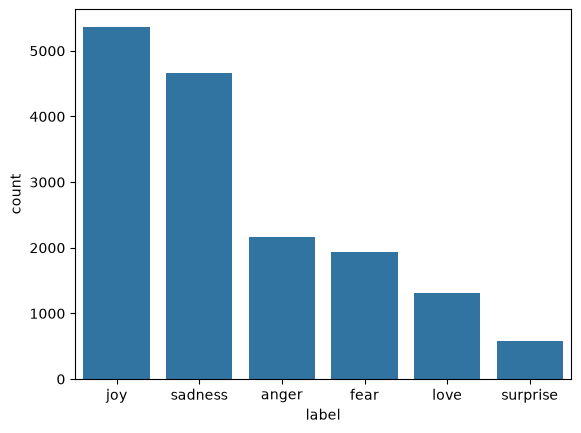

In [8]:
sns.countplot(x='label',data=df_train,order=df_train['label'].value_counts().index)

# Data Preprocessing Using NLP

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer # for converting text to numbers
from tensorflow.keras.preprocessing.sequence import pad_sequences  # for converting all sentences in same lenghs

In [10]:
max_words=10000 # max word in vocabulary
tokenizer=Tokenizer(num_words=max_words,oov_token='') # oov - out of vocabulary
tokenizer.fit_on_texts(df_train['text'])
# print(tokenizer.word_index)

In [11]:
train_sequence =tokenizer.texts_to_sequences(df_train['text'])
test_sequence =tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post',truncating='post') # every sentence 50 tokens long(add zeros after work)
padded_test_sequence = pad_sequences(test_sequence,maxlen=50,padding='post',truncating='post')

train_label = np.array(
    emotion_data['train']['label'],
    dtype=np.int32
)

test_label = np.array(
    emotion_data['test']['label'],
    dtype=np.int32
)

train_label=np.array(train_label)
test_label=np.array(test_label)


num_classes = len(np.unique(train_label))
num_classes

print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max sentence lenght: {padded_train_sequence.shape[1]}")
print(f"Number of Classes:{num_classes}")

Vocabulary Size: 15213
Max sentence lenght: 50
Number of Classes:6


# Training Control Techniques

In [12]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes = np.unique(train_label),
    y=train_label)
class_weights_dict = dict(enumerate(class_weights))  #don't ignore the emotions that have fewer training examples.

from tensorflow.keras.callbacks import EarlyStopping # stop training when validation performance stops improving (in this case if loss function is not improve after 3 iterations then stop the process and this is helpul for overfitting)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True)  # restore after stopping improving for choose best weight we can restore

# Plain Foundational Models (RNN,LSTM,GRU) no bidirectional

# RNN

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Embedding,Dense,Dropout,LSTM,GRU

rnn_model=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    SimpleRNN(units=128,return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax') ])#output layer

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [14]:
rnn_model.fit(
    padded_train_sequence,
    train_label,
    validation_data=(padded_test_sequence,test_label),
    epochs=20,
    batch_size=32,
    class_weight =class_weights_dict,
    callbacks=[early_stopping]
)

rnn_loss,rnn_accuracy=rnn_model.evaluate(padded_test_sequence,test_label)

print(f"RNN Loss:{rnn_loss}")
print(f"RNN Accuracy :{rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 66ms/step - accuracy: 0.1680 - loss: 2.0470 - val_accuracy: 0.0775 - val_loss: 1.8205
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.1428 - loss: 1.8783 - val_accuracy: 0.1710 - val_loss: 1.7667
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.1374 - loss: 1.8324 - val_accuracy: 0.0445 - val_loss: 1.8000
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.1362 - loss: 1.8065 - val_accuracy: 0.3495 - val_loss: 1.7918
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - accuracy: 0.1457 - loss: 1.8020 - val_accuracy: 0.2885 - val_loss: 1.7973
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1710 - loss: 1.7667
RNN Loss:1.7666993141174316
RNN Accuracy :0.17100000381469727


# LSTM Model

In [15]:
lstm_model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=50
    ),

    LSTM(
        units=128,
        return_sequences=True
    ),

    Dropout(0.5),

    LSTM(
        units=64
    ),

    Dropout(0.5),

    Dense(
        units=num_classes,
        activation='softmax'
    )
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
lstm_model.fit(
    padded_train_sequence,
    train_label,
    validation_data=(padded_test_sequence, test_label),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(
    padded_test_sequence,
    test_label
)

print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 123ms/step - accuracy: 0.1446 - loss: 1.7946 - val_accuracy: 0.3470 - val_loss: 1.7633
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 78s 114ms/step - accuracy: 0.1437 - loss: 1.7938 - val_accuracy: 0.0490 - val_loss: 1.7851
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 112ms/step - accuracy: 0.1528 - loss: 1.7923 - val_accuracy: 0.0370 - val_loss: 1.7933
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 64s 127ms/step - accuracy: 0.1951 - loss: 1.7690 - val_accuracy: 0.2530 - val_loss: 1.7368
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 106ms/step - accuracy: 0.3210 - loss: 1.6011 - val_accuracy: 0.3540 - val_loss: 1.5935
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 51s 102ms/step - accuracy: 0.4848 - loss: 1.2814 - val_accuracy: 0.6600 - val_loss: 0.9568
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 102ms/step - accuracy: 0.7459 - loss: 0.7314 - val_accuracy: 0.8240 - val_loss: 0.6178
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 51s 102ms/step - accuracy: 0.8554 - loss: 0

# GRU

In [16]:
gru_model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=50
    ),

    GRU(
        units=128,
        return_sequences=True
    ),

    Dropout(0.5),

    GRU(
        units=64
    ),

    Dropout(0.5),

    Dense(
        units=num_classes,
        activation='softmax'
    )
])

gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
gru_model.fit(
    padded_train_sequence,
    train_label,
    validation_data=(padded_test_sequence, test_label),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(
    padded_test_sequence,
    test_label
)

print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 52s 93ms/step - accuracy: 0.1460 - loss: 1.7971 - val_accuracy: 0.0350 - val_loss: 1.7970
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 109ms/step - accuracy: 0.1635 - loss: 1.7955 - val_accuracy: 0.0385 - val_loss: 1.8020
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 74s 92ms/step - accuracy: 0.1530 - loss: 1.7940 - val_accuracy: 0.1130 - val_loss: 1.7792
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy: 0.1412 - loss: 1.7939 - val_accuracy: 0.0360 - val_loss: 1.7897
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3400s 7s/step - accuracy: 0.1709 - loss: 1.7896 - val_accuracy: 0.0410 - val_loss: 1.8047
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 133ms/step - accuracy: 0.1761 - loss: 1.7695 - val_accuracy: 0.1400 - val_loss: 1.8409
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.1130 - loss: 1.7792
GRU Loss: 1.7791938781738281
GRU Accuracy: 0.11299999803304672


# Ranking and Selection

In [17]:
result_df = pd.DataFrame({
    'Model':['RNN','LSTM','GRU'],
    'Test Loss':[rnn_loss,lstm_loss,gru_loss],
    'Test Accuracy':[rnn_accuracy,lstm_accuracy,gru_accuracy]}).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
1,LSTM,0.443448,0.876
0,RNN,1.766699,0.171
2,GRU,1.779194,0.113


# Advanced Bidirection Models

# LSTM Bidirectional

In [18]:
from tensorflow.keras.layers import Bidirectional

BiLSTM = Sequential([
    Embedding(input_dim=max_words,output_dim=300,input_length=50),
    Bidirectional(LSTM(128,return_sequences=True)),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(num_classes,activation='softmax') # output layer
])

BiLSTM.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
BiLSTM.summary()

c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
BiLSTM.fit(
    padded_train_sequence,
    train_label,
    validation_data=(padded_test_sequence,test_label),
    epochs=20,
    batch_size=20,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 210s 249ms/step - accuracy: 0.6371 - loss: 0.9359 - val_accuracy: 0.8870 - val_loss: 0.3821
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 246s 303ms/step - accuracy: 0.9149 - loss: 0.2529 - val_accuracy: 0.9165 - val_loss: 0.2251
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 234s 267ms/step - accuracy: 0.9362 - loss: 0.1787 - val_accuracy: 0.9100 - val_loss: 0.2458
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 238s 236ms/step - accuracy: 0.9501 - loss: 0.1429 - val_accuracy: 0.9030 - val_loss: 0.2374
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 197s 246ms/step - accuracy: 0.9636 - loss: 0.0943 - val_accuracy: 0.9090 - val_loss: 0.2972


In [27]:
BiLSTM_loss, BiLSTM_accuracy = BiLSTM.evaluate(
    padded_test_sequence,
    test_label
)
print("Loss",BiLSTM_loss)
print("Accuracy",BiLSTM_accuracy)


63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.9165 - loss: 0.2251
Loss 0.22511057555675507
Accuracy 0.9164999723434448


# GRU Bidirectional

In [28]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim=max_words,output_dim=300,input_length=50),
    Bidirectional(GRU(128,return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes,activation='softmax') # output layer
])

BiGRU.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
BiGRU.summary()

c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Train and Evaluate bidirectional Gru

In [29]:
BiGRU.fit(
    padded_train_sequence,
    train_label,
    validation_data=(padded_test_sequence,test_label),
    epochs=20,
    batch_size=20,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 212s 245ms/step - accuracy: 0.6545 - loss: 0.8888 - val_accuracy: 0.8960 - val_loss: 0.2887
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 186s 224ms/step - accuracy: 0.9269 - loss: 0.2123 - val_accuracy: 0.9255 - val_loss: 0.1987
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 217s 243ms/step - accuracy: 0.9451 - loss: 0.1519 - val_accuracy: 0.9185 - val_loss: 0.2517
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 200s 240ms/step - accuracy: 0.9571 - loss: 0.1218 - val_accuracy: 0.9185 - val_loss: 0.2552
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 183s 228ms/step - accuracy: 0.9678 - loss: 0.0961 - val_accuracy: 0.9230 - val_loss: 0.2442


In [31]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(
    padded_test_sequence,
    test_label
)

print("Loss",BiGRU_loss)
print("Accuracy",BiGRU_accuracy)


63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.9255 - loss: 0.1987
Loss 0.19870230555534363
Accuracy 0.9254999756813049


# Overall Evaluation and Bias Analysis
consolidate test metrics,plot raw and normalized confusion matrices and analyse bias

# Final Model Confusion Matrices (Raw Counts & Normalized %)

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step


<Axes: >

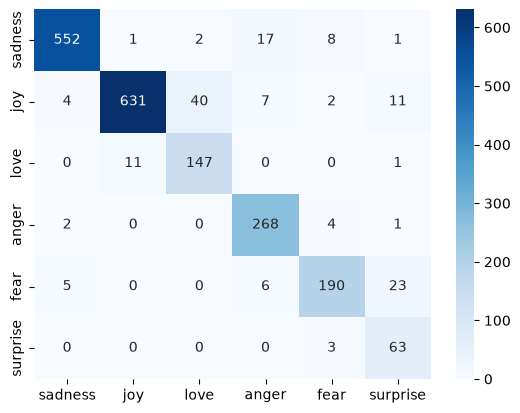

In [32]:
from sklearn.metrics import confusion_matrix
BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)
sns.heatmap(confusion_matrix(test_label,BiGRU_predictions),annot=True,fmt='d',cmap='Blues',xticklabels=label_names,yticklabels=label_names)

# FINAL PREDICTIONS

In [33]:
sample_texts = [
    "I cat't feel believe how happy I am right now,this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences=pad_sequences(sample_sequences,maxlen=50,padding='post',truncating='post')
sample_predictions=np.argmax(BiGRU.predict(sample_padded_sequences),axis=1)

for i in range(len(sample_texts)):
    print(f"Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
Text: I cat't feel believe how happy I am right now,this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


# Save Model & Tokenizer
Export trained model and tokenizer artifacts for API deployment.

In [34]:
import os
import pickle

model_dir='Artifacts'
os.makedirs(model_dir,exist_ok=True) 
import os
os.makedirs("Artifacts", exist_ok=True)
BiGRU.save("Artifacts/BiGRU_Model.keras")

# save our BiGRU Model

with open(os.path.join(model_dir,'tokenizer.pkl'),'wb') as file:
    pickle.dump(tokenizer,file)